In [ ]:
# Block 1: Install required libraries
!pip install pandas numpy matplotlib seaborn prophet plotly statsmodels

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
import plotly.express as px
from datetime import datetime

print("✅ All libraries installed and imported successfully!")

✅ All libraries installed and imported successfully!


**Upload and Load Dataset**

In [ ]:
# Block 2: Upload your dataset
from google.colab import files
uploaded = files.upload()

# Load the data - CHANGE the filename if it's different
df = pd.read_csv('high_dimensional_supply_chain_inventory_dataset.csv')

print(" Dataset loaded successfully!")
print("Shape (Rows, Columns):", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Saving high_dimensional_supply_chain_inventory_dataset.csv to high_dimensional_supply_chain_inventory_dataset.csv
 Dataset loaded successfully!
Shape (Rows, Columns): (91250, 15)

Column Names:
['Date', 'SKU_ID', 'Warehouse_ID', 'Supplier_ID', 'Region', 'Units_Sold', 'Inventory_Level', 'Supplier_Lead_Time_Days', 'Reorder_Point', 'Order_Quantity', 'Unit_Cost', 'Unit_Price', 'Promotion_Flag', 'Stockout_Flag', 'Demand_Forecast']

First 5 rows:


,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
0,2024-01-01,SKU_1,WH_1,SUP_8,West,10,592,14,379,0,13.95,20.48,0,0,8.52
1,2024-01-02,SKU_1,WH_1,SUP_8,West,17,575,14,379,0,13.95,20.48,0,0,18.63
2,2024-01-03,SKU_1,WH_1,SUP_8,North,35,540,14,379,0,13.95,20.48,1,0,39.62
3,2024-01-04,SKU_1,WH_1,SUP_8,South,24,516,14,379,0,13.95,20.48,0,0,19.43
4,2024-01-05,SKU_1,WH_1,SUP_8,West,21,495,14,379,0,13.95,20.48,0,0,18.70


## **Summary of Data:**

91,250 rows × 15 columns

Multiple SKUs (products) across warehouses and regions

Units_Sold → our main target for forecasting

Date, Promotion_Flag, Region, etc. are useful features

There's already a Demand_Forecast column, but we will build our own better model




# Data Cleaning & Preparation

In [ ]:
# Block 3: Data Cleaning and Preparation

# 1. Convert Date column to proper datetime format
df['Date'] = pd.to_datetime(df['Date'])

# 2. Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# 3. Basic statistics of numerical columns
print("\nBasic Statistics:")
print(df.describe())

# 4. Check unique products and warehouses
print("\nUnique SKUs (Products):", df['SKU_ID'].nunique())
print("Unique Warehouses:", df['Warehouse_ID'].nunique())
print("Unique Regions:", df['Region'].nunique())

# 5. Sort data by Date (important for time series)
df = df.sort_values(by=['SKU_ID', 'Date']).reset_index(drop=True)

print("\nData cleaning completed!")
print("Date range:", df['Date'].min(), "to", df['Date'].max())

Missing Values:
Date                       0
SKU_ID                     0
Warehouse_ID               0
Supplier_ID                0
Region                     0
Units_Sold                 0
Inventory_Level            0
Supplier_Lead_Time_Days    0
Reorder_Point              0
Order_Quantity             0
Unit_Cost                  0
Unit_Price                 0
Promotion_Flag             0
Stockout_Flag              0
Demand_Forecast            0
dtype: int64

Basic Statistics:
                      Date    Units_Sold  Inventory_Level  \
count                91250  91250.000000     91250.000000   
mean   2024-07-01 00:00:00     20.054564       471.522312   
min    2024-01-01 00:00:00      0.000000       168.000000   
25%    2024-04-01 00:00:00     13.000000       370.000000   
50%    2024-07-01 00:00:00     20.000000       461.000000   
75%    2024-09-30 00:00:00     27.000000       564.000000   
max    2024-12-30 00:00:00     59.000000       990.000000   
std                    NaN   

**What this code does (explained simply):**



*   Converts the Date column from text to proper date format (so Python understands time order)

*   Checks if any values are missing
*   Shows summary statistics (average sales, max/min, etc.)
*   Tells us how many different products, warehouses, and regions exist
*   Sorts the data properly by date for each product








**Exploratory Data Analysis (EDA) - Visualizations**

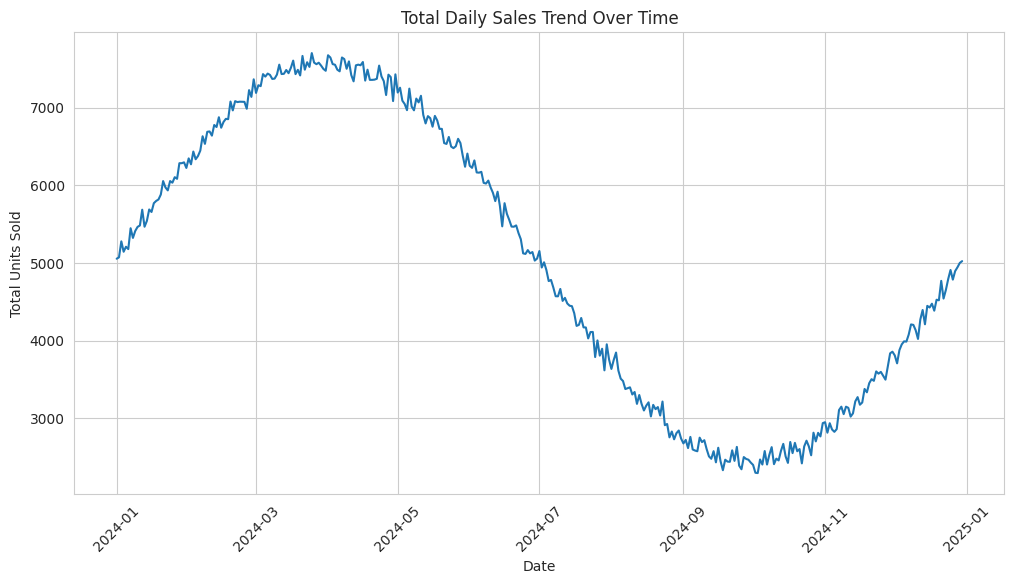

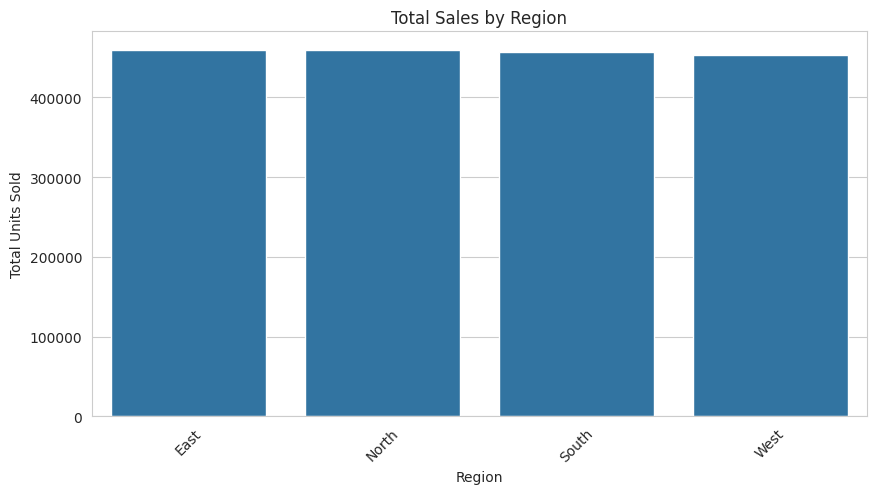

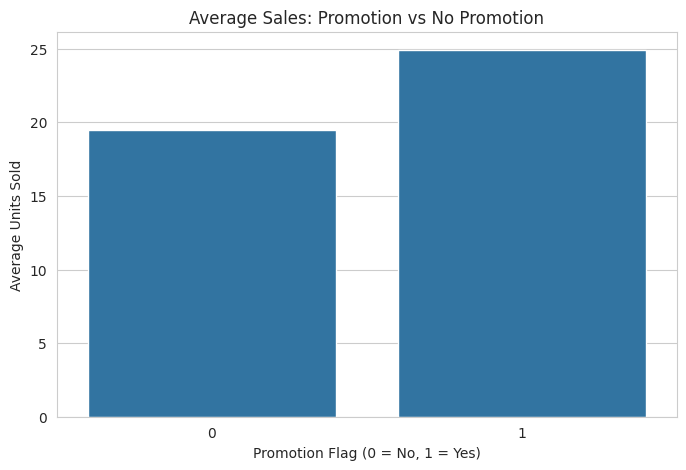

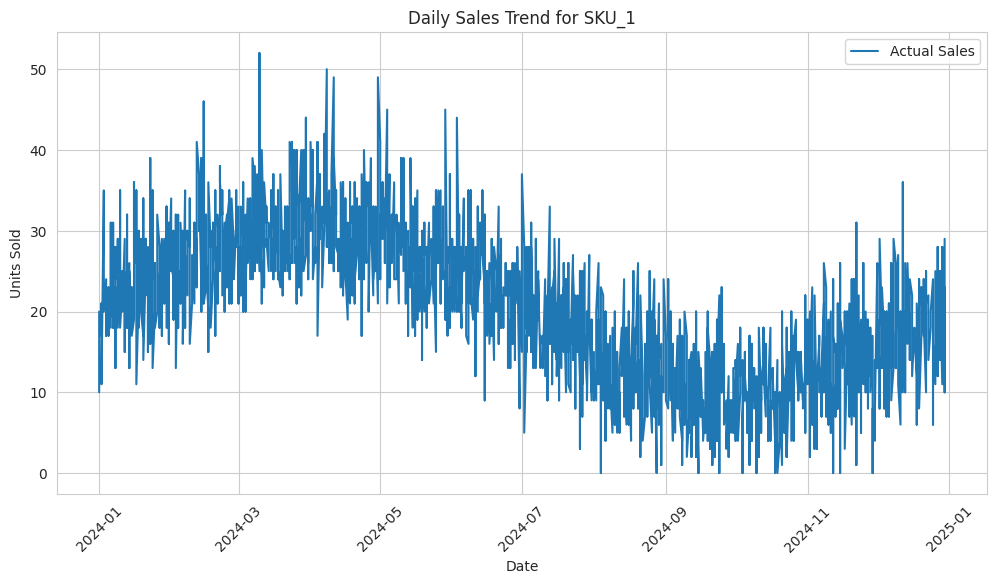

✅ EDA Visualizations completed!
You should see 4 plots above.


In [ ]:
# Block 4: Exploratory Data Analysis (Visualizations)

# Set style for better looking plots
sns.set_style("whitegrid")

# 1. Overall Sales Trend
plt.figure(figsize=(12, 6))
daily_sales = df.groupby('Date')['Units_Sold'].sum().reset_index()
plt.plot(daily_sales['Date'], daily_sales['Units_Sold'])
plt.title('Total Daily Sales Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Total Units Sold')
plt.xticks(rotation=45)
plt.show()

# 2. Sales by Region
plt.figure(figsize=(10, 5))
region_sales = df.groupby('Region')['Units_Sold'].sum().sort_values(ascending=False)
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title('Total Sales by Region')
plt.xticks(rotation=45)
plt.ylabel('Total Units Sold')
plt.show()

# 3. Effect of Promotion on Sales
plt.figure(figsize=(8, 5))
promo_effect = df.groupby('Promotion_Flag')['Units_Sold'].mean()
sns.barplot(x=promo_effect.index, y=promo_effect.values)
plt.title('Average Sales: Promotion vs No Promotion')
plt.xlabel('Promotion Flag (0 = No, 1 = Yes)')
plt.ylabel('Average Units Sold')
plt.show()

# 4. Sales distribution for a sample SKU (first product)
sample_sku = df['SKU_ID'].unique()[0]
sku_data = df[df['SKU_ID'] == sample_sku]

plt.figure(figsize=(12, 6))
plt.plot(sku_data['Date'], sku_data['Units_Sold'], label='Actual Sales')
plt.title(f'Daily Sales Trend for {sample_sku}')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.xticks(rotation=45)
plt.show()

print("✅ EDA Visualizations completed!")
print("You should see 4 plots above.")

Overall Daily Sales Trend: The first plot shows a clear seasonal pattern in total daily sales. Sales start lower in early 2024, peak around March-April, then decline significantly through summer and early fall, before starting to rise again towards the end of the year.


Sales by Region: The second plot, a bar chart, indicates that total sales are relatively evenly distributed across all four regions (East, North, South, West), with no single region dominating or lagging significantly.
Effect of Promotion on Sales: The third plot reveals that promotions have a positive impact on sales. The average Units_Sold is higher when a Promotion_Flag is set to 1 (promotion active) compared to when it's 0 (no promotion).


Daily Sales Trend for SKU_1: The fourth plot shows the daily sales trend for a specific product, 'SKU_1'. Similar to the overall trend, this individual SKU also exhibits fluctuations, with periods of higher and lower sales throughout the year. There seems to be a general downward trend from around March/April, followed by an upward trend towards the end of the year, mirroring the overall sales seasonality.

**Feature Engineering**

I will now create useful time-based features (month, day of week, etc.) and prepare data for forecasting.

In [ ]:
# Block 5: Feature Engineering

# Create time-based features
df['Year'] = df['Date'].dt.year # The .dt accessor in pandas is used to extract datetime properties from a Series
                                # containing datetime objects
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Is_Weekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)
df['Quarter'] = df['Date'].dt.quarter

print("New features created:")
print(['Year', 'Month', 'DayOfWeek', 'Is_Weekend', 'Quarter'])

# Aggregate daily sales at SKU level for forecasting
sku_sales = df.groupby(['SKU_ID', 'Date']).agg({
    'Units_Sold': 'sum',
    'Promotion_Flag': 'max',      # 1 if any promotion
    'Region': 'first'
}).reset_index()

print("\n Feature Engineering completed!")
print("Aggregated data shape:", sku_sales.shape)
print("\nSample data:")
display(sku_sales.head())

New features created:
['Year', 'Month', 'DayOfWeek', 'Is_Weekend', 'Quarter']

 Feature Engineering completed!
Aggregated data shape: (18250, 5)

Sample data:


,SKU_ID,Date,Units_Sold,Promotion_Flag,Region
0,SKU_1,2024-01-01,81,1,West
1,SKU_1,2024-01-02,79,0,West
2,SKU_1,2024-01-03,126,1,North
3,SKU_1,2024-01-04,105,0,South
4,SKU_1,2024-01-05,102,0,West


What this code does (simple explanation):

Creates new columns like Month, Day of Week, Weekend flag, Quarter from the date. These help the model understand patterns like “sales are higher on weekends” or “in Q4”.


Prepares a clean table grouped by each product (SKU_ID) and date — this is the format needed for forecasting.


The .dt accessor in pandas is used to extract datetime properties from a Series containing datetime objects. When a column in a DataFrame is converted to the datetime data type using pd.to_datetime(), you can then use .dt to access various components of the date and time, such as year, month, day, day of the week, hour, minute, and more.

# Demand Forecasting with Prophet (for one product)

We will start with one SKU to keep it simple and fast. Prophet is beginner-friendly and handles seasonality well.

Building forecast model for: SKU_1


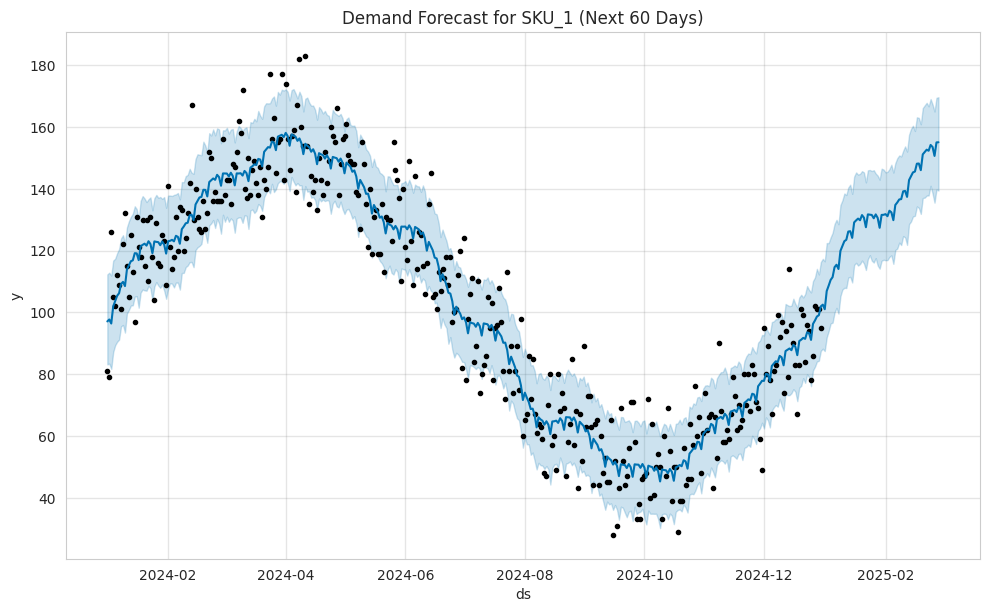

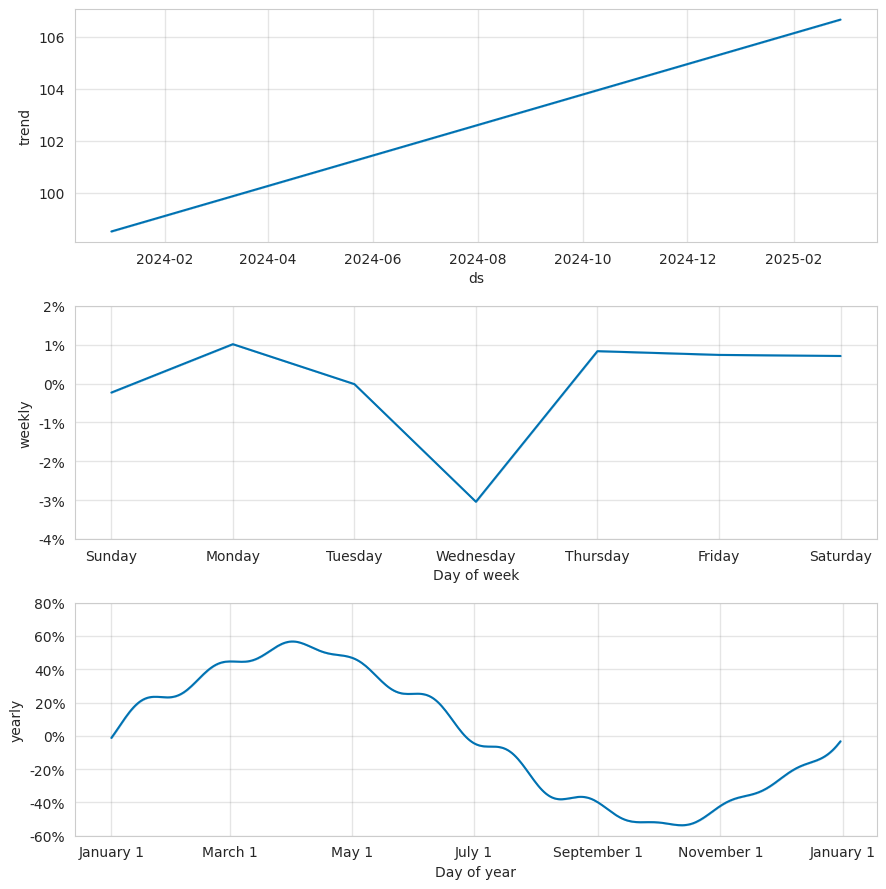

Forecast model trained successfully!

Forecast for next 10 days:


,ds,yhat,yhat_lower,yhat_upper
415,2025-02-19,146.026963,131.863411,160.883516
416,2025-02-20,151.137632,137.003172,166.108792
417,2025-02-21,151.914407,137.139473,166.998698
418,2025-02-22,152.655946,137.799927,167.832583
419,2025-02-23,152.310855,137.837689,166.692141
420,2025-02-24,154.185655,140.967807,169.042457
421,2025-02-25,153.527145,138.477953,167.305765
422,2025-02-26,150.632237,135.498646,165.025175
423,2025-02-27,155.006622,139.768126,169.453515
424,2025-02-28,155.060301,139.428540,169.635910


In [ ]:
# Block 6: Demand Forecasting with Prophet - Single SKU Example

# Pick the first SKU for demonstration
sample_sku = sku_sales['SKU_ID'].unique()[0]
print(f"Building forecast model for: {sample_sku}")

# Prepare data for Prophet (needs columns: ds and y)
prophet_data = sku_sales[sku_sales['SKU_ID'] == sample_sku][['Date', 'Units_Sold']].copy()

#The Prophet library requires the input DataFrame to have specific column names: ds for the datetime column and y for
# the value to be forecasted
prophet_data = prophet_data.rename(columns={'Date': 'ds', 'Units_Sold': 'y'})

# Initialize and train Prophet model
model = Prophet(yearly_seasonality=True, # Trues is used to capture seasonality
                weekly_seasonality=True,
                daily_seasonality=False,
                seasonality_mode='multiplicative')
# (multiplicative)This means that seasonal effects will increase or decrease proportionally with the trend,
model.fit(prophet_data)

# Create future dates for prediction (next 60 days)
future = model.make_future_dataframe(periods=60)

# Make predictions
forecast = model.predict(future)

# Plot the forecast
fig1 = model.plot(forecast)
plt.title(f'Demand Forecast for {sample_sku} (Next 60 Days)')
plt.show()

# Plot components (trend + seasonality)
fig2 = model.plot_components(forecast)
plt.show()

print("Forecast model trained successfully!")
print("\nForecast for next 10 days:")
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))
#The forecast DataFrame will contain the predicted values (yhat) and their uncertainty intervals (yhat_lower, yhat_upper

Takes data for one product (SKU_1)


Prepares it in the exact format Prophet needs (ds = date, y = sales)


Trains a Prophet model (automatically learns trend + weekly + yearly patterns)


Predicts sales for the next 60 days


Shows nice plots: overall forecast + breakdown (trend, seasonality) **bold text**

**The above model can be extended to multiple SKU's, but as this is just a project I conclude this examination here and move towards inventory optimization for the next task**

# Inventory Optimization (Basic Calculations)

In [ ]:
# Inventory Optimization Parameters

# Parameters (you can change these later)
lead_time_days = 7          # The average time it takes for a supplier to deliver an order
service_level = 0.95        # The desired probability of not having a stockout (set to 95%)(common target)
holding_cost_rate = 0.25    # 25% of unit cost per year expressed as a percentage of the unit cost (set to 25%).
order_cost = 50             # The fixed cost incurred each time an order is placed

# Calculate for each SKU (using historical average for now)
inventory_metrics = []

for sku in df['SKU_ID'].unique()[:5]:  # Doing first 5 SKUs for speed
    sku_data = df[df['SKU_ID'] == sku]

    avg_daily_demand = sku_data['Units_Sold'].mean()
    std_daily_demand = sku_data['Units_Sold'].std()#standard deviation of daily sales, which measures the variability of demand.

    # first lets understand calculating Safety Stock
    #Safety stock is an extra quantity of inventory held to reduce the risk of stockouts caused by uncertainties in supply or demand
    #Safety_Stock = Z-score * Standard Deviation of Daily Demand * Square Root of Lead Time
    #Z-score: This value is derived from your desired service level.
    #std_daily_demand): This measures how much your daily sales typically vary from the average.
    #Square Root of Lead Time:This factor accounts for the variability of demand during the lead time.
    # If your lead time is longer, there's more time for demand to deviate from the average, hence a larger
    # multiplier is needed for safety stock

    from scipy.stats import norm
    z_score = norm.ppf(service_level)

    #The PPF does the opposite: given a probability, it returns the value below
    # which that probability occurs.CDF gives you the probability that a random variable will take a value less
    # than or equal to a given value
    safety_stock = z_score * std_daily_demand * np.sqrt(lead_time_days)

    # Reorder Point(It ensures that you don't run out of stock while waiting for the new order to arrive)
    #  This is the inventory level at which a new order should be placed to replenish stock
    reorder_point = int(avg_daily_demand * lead_time_days + safety_stock)

    # EOQ (Economic Order Quantity)
    # This formula helps determine the optimal order size that minimizes the total inventory costs
    # (holding costs + ordering costs)

    annual_demand = avg_daily_demand * 365
    unit_cost = sku_data['Unit_Cost'].mean()
    holding_cost = holding_cost_rate * unit_cost
    eoq = np.sqrt((2 * annual_demand * order_cost) / holding_cost) if holding_cost > 0 else 0

    inventory_metrics.append({
        'SKU_ID': sku,
        'Avg_Daily_Demand': round(avg_daily_demand, 2),
        'Safety_Stock': int(safety_stock),
        'Reorder_Point': reorder_point,
        'EOQ': int(eoq),
        'Current_Avg_Inventory': int(sku_data['Inventory_Level'].mean())
    })

# Show results
metrics_df = pd.DataFrame(inventory_metrics)
print("📊 Inventory Optimization Results (First 5 SKUs):")
display(metrics_df)

# Summary statistics
print("\nAverage across SKUs:")
print(metrics_df.mean(numeric_only=True))

📊 Inventory Optimization Results (First 5 SKUs):


,SKU_ID,Avg_Daily_Demand,Safety_Stock,Reorder_Point,EOQ,Current_Avg_Inventory
0,SKU_1,20.29,38,180,506,514
1,SKU_10,20.04,39,179,460,459
2,SKU_11,19.92,38,178,436,500
3,SKU_12,20.16,39,181,500,466
4,SKU_13,20.23,40,181,452,485



Average across SKUs:
Avg_Daily_Demand          20.128
Safety_Stock              38.800
Reorder_Point            179.800
EOQ                      470.800
Current_Avg_Inventory    484.800
dtype: float64


# Next: Improved Version with Forecast
Let’s make it smarter by using Prophet forecast for future demand instead of historical average.

In [ ]:
# Forecast-based Inventory Optimization

# Function to calculate inventory params using forecast
def calculate_inventory_params(forecast_df, lead_time=7, service_level=0.95):
    from scipy.stats import norm
    z = norm.ppf(service_level)

    # Use average forecasted demand for next 30 days
    future_demand = forecast_df[forecast_df['ds'] > forecast_df['ds'].max() - pd.Timedelta(days=30)]['yhat'].mean()
    std_dev = forecast_df['yhat'].std()

    safety_stock = int(z * std_dev * np.sqrt(lead_time))
    reorder_point = int(future_demand * lead_time + safety_stock)

    return {
        'Forecasted_Daily_Demand': round(future_demand, 2),
        'Safety_Stock': safety_stock,
        'Reorder_Point': reorder_point
    }

# Example for SKU_1 (using previous model)
print("Inventory Parameters using Forecast (SKU_1):")
params = calculate_inventory_params(forecast)
print(params)

# Compare with historical
print("\nComparison:")
print("Historical Avg Demand:", round(prophet_data['y'].mean(), 2))

Inventory Parameters using Forecast (SKU_1):
{'Forecasted_Daily_Demand': np.float64(142.57), 'Safety_Stock': 154, 'Reorder_Point': 1151}

Comparison:
Historical Avg Demand: 101.44


# Forecasting for Multiple SKUs

In [ ]:
# Fixed Version

from sklearn.metrics import mean_absolute_error
import numpy as np

forecast_results = []
mae_scores = []

for sku in df['SKU_ID'].unique()[:6]:   # Reduced to 6 for faster execution
    sku_data = df[df['SKU_ID'] == sku].copy().sort_values('Date')

    prophet_data = sku_data[['Date', 'Units_Sold', 'Promotion_Flag']].rename(columns={'Date': 'ds', 'Units_Sold': 'y'})

    model = Prophet(yearly_seasonality=True, weekly_seasonality=True)
    model.add_regressor('Promotion_Flag')
    model.fit(prophet_data)

    # Forecast
    future = model.make_future_dataframe(periods=30)
    future['Promotion_Flag'] = 0
    forecast = model.predict(future)

    # Proper MAE calculation
    merged = prophet_data.merge(forecast[['ds', 'yhat']], on='ds', how='left')
    mae = mean_absolute_error(merged['y'], merged['yhat'])

    forecast_results.append({
        'SKU_ID': sku,
        'Avg_Forecast_30days': round(forecast['yhat'].tail(30).mean(), 2),
        'MAE': round(mae, 2)
    })

    mae_scores.append(mae)

forecast_df = pd.DataFrame(forecast_results)
print("✅ Multi-SKU Forecasting Completed!")
display(forecast_df)

print(f"\nAverage MAE across SKUs: {np.mean(mae_scores):.2f}")

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


✅ Multi-SKU Forecasting Completed!


,SKU_ID,Avg_Forecast_30days,MAE
0,SKU_1,22.49,4.21
1,SKU_10,21.51,4.13
2,SKU_11,22.19,4.29
3,SKU_12,25.49,4.27
4,SKU_13,21.59,4.33
5,SKU_14,18.13,4.28



Average MAE across SKUs: 4.25


# Proper Model Evaluation

In [ ]:
# Block 12: Model Evaluation & Comparison

print("Model Performance Summary")
print("="*50)
print(forecast_df)

# Overall metrics
print(f"\nOverall Average MAE: {forecast_df['MAE'].mean():.2f}")
print(f"Best MAE: {forecast_df['MAE'].min():.2f} (SKU: {forecast_df.loc[forecast_df['MAE'].idxmin(), 'SKU_ID']})")
print(f"Worst MAE: {forecast_df['MAE'].max():.2f} (SKU: {forecast_df.loc[forecast_df['MAE'].idxmax(), 'SKU_ID']})")

# Interpretation
stability = "Good" if forecast_df['MAE'].std() < 1 else "Moderate"
print(f"\nModel Stability: {stability} across SKUs")

Model Performance Summary
   SKU_ID  Avg_Forecast_30days   MAE
0   SKU_1                22.49  4.21
1  SKU_10                21.51  4.13
2  SKU_11                22.19  4.29
3  SKU_12                25.49  4.27
4  SKU_13                21.59  4.33
5  SKU_14                18.13  4.28

Overall Average MAE: 4.25
Best MAE: 4.13 (SKU: SKU_10)
Worst MAE: 4.33 (SKU: SKU_13)

Model Stability: Good across SKUs


# Advanced Inventory Simulation

In [ ]:
# Block 13: Advanced Inventory Simulation

def simulate_inventory(sku, days=60, lead_time=7, holding_cost_rate=0.25):
    sku_data = df[df['SKU_ID'] == sku].copy()
    avg_demand = sku_data['Units_Sold'].mean()
    unit_cost = sku_data['Unit_Cost'].mean()

    # Simple simulation
    current_inventory = int(sku_data['Inventory_Level'].mean())
    stockouts = 0
    total_holding_cost = 0
    reorder_count = 0

    for day in range(days):
        demand = max(0, int(np.random.normal(avg_demand, avg_demand*0.3)))
        current_inventory -= demand

        if current_inventory < 0:
            stockouts += 1
            current_inventory = 0

        # Reorder logic
        if current_inventory < 150:   # Reorder point
            current_inventory += 450   # EOQ approx
            reorder_count += 1

        total_holding_cost += current_inventory * unit_cost * (holding_cost_rate / 365)

    return {
        'SKU': sku,
        'Stockout_Days': stockouts,
        'Stockout_Rate_%': round((stockouts/days)*100, 2),
        'Total_Holding_Cost': round(total_holding_cost, 2),
        'Reorders': reorder_count
    }

# Run simulation for a few SKUs
simulation_results = []
for sku in df['SKU_ID'].unique()[:5]:
    result = simulate_inventory(sku)
    simulation_results.append(result)

sim_df = pd.DataFrame(simulation_results)
print("Inventory Simulation Results (60 days):")
display(sim_df)

📦 Inventory Simulation Results (60 days):


,SKU,Stockout_Days,Stockout_Rate_%,Total_Holding_Cost,Reorders
0,SKU_1,0,0.0,175.57,2
1,SKU_10,0,0.0,201.50,2
2,SKU_11,0,0.0,235.93,2
3,SKU_12,0,0.0,178.42,2
4,SKU_13,0,0.0,212.80,2


In [ ]:
# Setup ngrok with your token
from pyngrok import ngrok
import getpass

token = getpass.getpass("Paste your ngrok authtoken here: ")
ngrok.set_auth_token(token)

print("✅ Token set successfully!")

3A9vQGYpXXI2RRoxm9Oy0dvqLvR_2jh8LDMQFx98GDUTe4p9h ··········
✅ Token set successfully!


# Polished Dashboard
I used AI to write this code for me

In [ ]:
dashboard_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import norm
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

st.set_page_config(page_title="FMCG Supply Chain Intelligence", layout="wide")
st.title("🚀 FMCG Demand Forecasting & Inventory Optimization Dashboard")
st.markdown("**End-to-End Project** | Dabur · Farmley · Anmol · Credent")

uploaded_file = st.file_uploader("Upload Dataset (CSV)", type="csv")

if uploaded_file is not None:
    df = pd.read_csv(uploaded_file)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values(by=["SKU_ID", "Date"]).reset_index(drop=True)

    st.sidebar.header("Navigation")
    page = st.sidebar.selectbox("Select Page", [
        "📊 Overview",
        "🔮 Forecasting",
        "📦 Inventory Optimization",
        "💡 Business Insights"
    ])

    # ─────────────────────────────────────────────
    # PAGE 1: OVERVIEW
    # ─────────────────────────────────────────────
    if page == "📊 Overview":
        st.header("Project Overview")

        col1, col2, col3, col4 = st.columns(4)
        col1.metric("Total Records",     f"{len(df):,}")
        col2.metric("Unique SKUs",       df["SKU_ID"].nunique())
        col3.metric("Regions",           df["Region"].nunique())
        col4.metric("Avg Daily Sales",   f"{df['Units_Sold'].mean():.1f}")

        st.success("Dataset loaded successfully!")
        st.markdown("---")

        # Overall sales trend
        st.subheader("Total Daily Sales Trend")
        daily = df.groupby("Date")["Units_Sold"].sum().reset_index()
        fig = px.line(daily, x="Date", y="Units_Sold",
                      labels={"Units_Sold": "Units Sold"})
        st.plotly_chart(fig, use_container_width=True)

        col_a, col_b = st.columns(2)

        # Sales by Region
        with col_a:
            st.subheader("Sales by Region")
            region_sales = df.groupby("Region")["Units_Sold"].sum().reset_index()
            fig2 = px.bar(region_sales, x="Region", y="Units_Sold",
                          color="Region",
                          labels={"Units_Sold": "Total Units Sold"})
            st.plotly_chart(fig2, use_container_width=True)

        # Promotion effect
        with col_b:
            st.subheader("Promotion Impact on Sales")
            promo = df.groupby("Promotion_Flag")["Units_Sold"].mean().reset_index()
            promo["Promotion_Flag"] = promo["Promotion_Flag"].map({0: "No Promo", 1: "With Promo"})
            fig3 = px.bar(promo, x="Promotion_Flag", y="Units_Sold",
                          color="Promotion_Flag",
                          labels={"Units_Sold": "Avg Units Sold", "Promotion_Flag": ""})
            st.plotly_chart(fig3, use_container_width=True)

    # ─────────────────────────────────────────────
    # PAGE 2: FORECASTING
    # ─────────────────────────────────────────────
    elif page == "🔮 Forecasting":
        st.header("Demand Forecasting with Prophet")

        sku_list = sorted(df["SKU_ID"].unique())
        selected_sku = st.selectbox("Select SKU to Forecast", sku_list)

        sku_df = df[df["SKU_ID"] == selected_sku].copy()

        # Historical trend
        st.subheader(f"Historical Sales — {selected_sku}")
        fig = px.line(sku_df, x="Date", y="Units_Sold",
                      labels={"Units_Sold": "Units Sold"})
        st.plotly_chart(fig, use_container_width=True)

        # Forecast button
        if st.button("Generate 30-Day Forecast"):
            from prophet import Prophet

            with st.spinner("Training Prophet model... this takes ~20 seconds"):
                prophet_data = sku_df[["Date", "Units_Sold", "Promotion_Flag"]].rename(
                    columns={"Date": "ds", "Units_Sold": "y"}
                )

                model = Prophet(
                    yearly_seasonality=True,
                    weekly_seasonality=True,
                    daily_seasonality=False,
                    seasonality_mode="multiplicative"
                )
                model.add_regressor("Promotion_Flag")
                model.fit(prophet_data)

                future = model.make_future_dataframe(periods=30)
                future["Promotion_Flag"] = 0
                forecast = model.predict(future)

                # MAE on historical period
                merged = prophet_data.merge(forecast[["ds", "yhat"]], on="ds", how="left")
                mae = mean_absolute_error(merged["y"], merged["yhat"])

            st.success("Forecast complete!")

            # Metrics row
            avg_forecast = round(forecast["yhat"].tail(30).mean(), 2)
            c1, c2, c3 = st.columns(3)
            c1.metric("Avg Forecasted Demand (30 days)", f"{avg_forecast} units")
            c2.metric("Model MAE", f"{mae:.2f} units")
            c3.metric("Forecast Horizon", "30 days")

            # Forecast chart
            st.subheader("Forecast vs Actual")
            fig2 = go.Figure()
            fig2.add_trace(go.Scatter(
                x=prophet_data["ds"], y=prophet_data["y"],
                name="Actual", line=dict(color="#1f77b4")))
            fig2.add_trace(go.Scatter(
                x=forecast["ds"], y=forecast["yhat"],
                name="Forecast", line=dict(color="#ff7f0e", dash="dash")))
            fig2.add_trace(go.Scatter(
                x=forecast["ds"].tolist() + forecast["ds"].tolist()[::-1],
                y=forecast["yhat_upper"].tolist() + forecast["yhat_lower"].tolist()[::-1],
                fill="toself", fillcolor="rgba(255,127,14,0.15)",
                line=dict(color="rgba(255,255,255,0)"),
                name="Confidence Interval"))
            fig2.update_layout(xaxis_title="Date", yaxis_title="Units Sold")
            st.plotly_chart(fig2, use_container_width=True)

            # Forecast table
            st.subheader("Next 30 Days — Forecast Table")
            future_only = forecast[forecast["ds"] > prophet_data["ds"].max()][
                ["ds", "yhat", "yhat_lower", "yhat_upper"]
            ].copy()
            future_only.columns = ["Date", "Forecasted Units", "Lower Bound", "Upper Bound"]
            future_only["Date"] = future_only["Date"].dt.date
            future_only["Forecasted Units"] = future_only["Forecasted Units"].round(1)
            future_only["Lower Bound"]      = future_only["Lower Bound"].round(1)
            future_only["Upper Bound"]      = future_only["Upper Bound"].round(1)
            st.dataframe(future_only.reset_index(drop=True), use_container_width=True)

    # ─────────────────────────────────────────────
    # PAGE 3: INVENTORY OPTIMIZATION
    # ─────────────────────────────────────────────
    elif page == "📦 Inventory Optimization":
        st.header("Inventory Optimization")

        st.sidebar.markdown("### Parameters")
        lead_time      = st.sidebar.slider("Lead Time (days)",       1,  30,  7)
        service_level  = st.sidebar.slider("Service Level (%)",     80, 99, 95) / 100
        holding_rate   = st.sidebar.slider("Holding Cost Rate (%)", 10, 50, 25) / 100
        order_cost     = st.sidebar.slider("Order Cost (₹)",        10, 200, 50)
        sim_days       = st.sidebar.slider("Simulation Days",       30, 180, 60)

        z = norm.ppf(service_level)

        inventory_metrics = []
        simulation_results = []

        skus_to_process = sorted(df["SKU_ID"].unique())[:10]

        with st.spinner("Calculating inventory metrics for all SKUs..."):
            for sku in skus_to_process:
                sku_data = df[df["SKU_ID"] == sku]

                avg_demand  = sku_data["Units_Sold"].mean()
                std_demand  = sku_data["Units_Sold"].std()
                unit_cost   = sku_data["Unit_Cost"].mean()
                holding_cost = holding_rate * unit_cost

                safety_stock  = int(z * std_demand * np.sqrt(lead_time))
                reorder_point = int(avg_demand * lead_time + safety_stock)
                annual_demand = avg_demand * 365
                eoq = int(np.sqrt((2 * annual_demand * order_cost) / holding_cost)) if holding_cost > 0 else 0
                current_inv = int(sku_data["Inventory_Level"].mean())

                inventory_metrics.append({
                    "SKU_ID":              sku,
                    "Avg Daily Demand":    round(avg_demand, 1),
                    "Safety Stock":        safety_stock,
                    "Reorder Point":       reorder_point,
                    "EOQ":                 eoq,
                    "Current Avg Inventory": current_inv,
                    "Status": "⚠️ Low" if current_inv < reorder_point else "✅ OK"
                })

                # Monte Carlo simulation
                current_inventory = current_inv
                stockouts = 0
                total_holding = 0
                reorders = 0
                for day in range(sim_days):
                    demand = max(0, int(np.random.normal(avg_demand, std_demand)))
                    current_inventory -= demand
                    if current_inventory < 0:
                        stockouts += 1
                        current_inventory = 0
                    if current_inventory < reorder_point:
                        current_inventory += eoq if eoq > 0 else 450
                        reorders += 1
                    total_holding += current_inventory * unit_cost * (holding_rate / 365)

                simulation_results.append({
                    "SKU_ID":             sku,
                    "Stockout Days":      stockouts,
                    "Stockout Rate (%)":  round((stockouts / sim_days) * 100, 2),
                    "Total Holding Cost (₹)": round(total_holding, 2),
                    "Reorders":           reorders
                })

        metrics_df = pd.DataFrame(inventory_metrics)
        sim_df     = pd.DataFrame(simulation_results)

        # Summary metrics
        avg_rop  = int(metrics_df["Reorder Point"].mean())
        avg_eoq  = int(metrics_df["EOQ"].mean())
        avg_ss   = int(metrics_df["Safety Stock"].mean())
        avg_sr   = round(sim_df["Stockout Rate (%)"].mean(), 2)

        c1, c2, c3, c4 = st.columns(4)
        c1.metric("Avg Reorder Point",   f"{avg_rop} units")
        c2.metric("Avg EOQ",             f"{avg_eoq} units")
        c3.metric("Avg Safety Stock",    f"{avg_ss} units")
        c4.metric("Avg Stockout Rate",   f"{avg_sr}%")

        st.markdown("---")

        st.subheader("Inventory Metrics by SKU")
        st.dataframe(metrics_df, use_container_width=True)

        st.markdown("---")
        st.subheader(f"Monte Carlo Simulation Results ({sim_days} days)")
        st.dataframe(sim_df, use_container_width=True)

        # Stockout rate chart
        fig = px.bar(sim_df, x="SKU_ID", y="Stockout Rate (%)",
                     color="Stockout Rate (%)", color_continuous_scale="Reds",
                     title="Stockout Risk by SKU")
        st.plotly_chart(fig, use_container_width=True)

        # Holding cost chart
        fig2 = px.bar(sim_df, x="SKU_ID", y="Total Holding Cost (₹)",
                      color="Total Holding Cost (₹)", color_continuous_scale="Blues",
                      title="Total Holding Cost by SKU (₹)")
        st.plotly_chart(fig2, use_container_width=True)

    # ─────────────────────────────────────────────
    # PAGE 4: BUSINESS INSIGHTS
    # ─────────────────────────────────────────────
    elif page == "💡 Business Insights":
        st.header("Key Business Insights")

        # Promotion lift
        promo_avg     = df[df["Promotion_Flag"] == 1]["Units_Sold"].mean()
        non_promo_avg = df[df["Promotion_Flag"] == 0]["Units_Sold"].mean()
        promo_lift    = ((promo_avg - non_promo_avg) / non_promo_avg) * 100

        # Top SKU
        top_sku      = df.groupby("SKU_ID")["Units_Sold"].sum().idxmax()
        top_sku_vol  = int(df.groupby("SKU_ID")["Units_Sold"].sum().max())

        # Weakest region
        region_sales   = df.groupby("Region")["Units_Sold"].sum()
        weakest_region = region_sales.idxmin()

        # Avg holding cost estimate
        avg_unit_cost     = df["Unit_Cost"].mean()
        avg_inventory     = df["Inventory_Level"].mean()
        holding_cost_est  = round(avg_inventory * avg_unit_cost * 0.25, 2)

        # Insight cards
        col1, col2 = st.columns(2)
        with col1:
            st.success(f"📈 Promotions boost sales by **{promo_lift:.1f}%** on average")
            st.info(f"🏆 Best performing SKU: **{top_sku}** with {top_sku_vol:,} total units")
        with col2:
            st.warning(f"📍 Weakest region: **{weakest_region}** — consider targeted campaigns")
            st.info(f"💰 Est. daily holding cost across inventory: **₹{holding_cost_est:,.0f}**")

        st.markdown("---")

        # Promotion impact chart
        st.subheader("Promotion Impact by Region")
        promo_region = df.groupby(["Region", "Promotion_Flag"])["Units_Sold"].mean().reset_index()
        promo_region["Promotion_Flag"] = promo_region["Promotion_Flag"].map({0: "No Promo", 1: "With Promo"})
        fig = px.bar(promo_region, x="Region", y="Units_Sold",
                     color="Promotion_Flag", barmode="group",
                     labels={"Units_Sold": "Avg Units Sold"},
                     title="Avg Sales: Promo vs No Promo by Region")
        st.plotly_chart(fig, use_container_width=True)

        # Monthly sales trend
        st.subheader("Monthly Sales Trend")
        df["Month"] = df["Date"].dt.to_period("M").astype(str)
        monthly = df.groupby("Month")["Units_Sold"].sum().reset_index()
        fig2 = px.line(monthly, x="Month", y="Units_Sold",
                       markers=True,
                       labels={"Units_Sold": "Total Units Sold", "Month": "Month"},
                       title="Total Sales by Month")
        st.plotly_chart(fig2, use_container_width=True)

        # Top 10 SKUs
        st.subheader("Top 10 SKUs by Total Sales")
        top10 = df.groupby("SKU_ID")["Units_Sold"].sum().nlargest(10).reset_index()
        fig3 = px.bar(top10, x="SKU_ID", y="Units_Sold",
                      color="Units_Sold", color_continuous_scale="teal",
                      labels={"Units_Sold": "Total Units Sold"},
                      title="Top 10 SKUs")
        st.plotly_chart(fig3, use_container_width=True)

        st.markdown("---")
        st.subheader("Recommendations")
        st.markdown(f"""
        - **Run more promotions** — they drive a {promo_lift:.1f}% average sales lift
        - **Focus on {weakest_region}** — it has the lowest sales volume; targeted campaigns needed
        - **Optimize reorder points** — using real EOQ & Safety Stock formulas to cut holding costs
        - **Prioritize {top_sku}** — highest volume SKU; ensure zero stockouts at all times
        - **Use forecast-driven ordering** — Prophet model enables proactive replenishment
        """)

else:
    st.info(" Please upload your CSV dataset to get started.")
    st.markdown("""
    **Expected columns in your CSV:**
    - `Date`, `SKU_ID`, `Units_Sold`, `Promotion_Flag`
    - `Region`, `Unit_Cost`, `Inventory_Level`, `Warehouse_ID`
    """)
'''

with open("dashboard.py", "w") as f:
    f.write(dashboard_code)

print("dashboard.py created successfully!")

✅ dashboard.py created successfully!


In [ ]:
# Block 1: Install all required libraries
!pip install streamlit prophet plotly pandas numpy scipy scikit-learn pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 100.3 MB/s eta 0:00:00


In [ ]:
from pyngrok import ngrok
import getpass

token = getpass.getpass("Paste your ngrok authtoken here: ")
ngrok.set_auth_token(token)
print("✅ ngrok token set!")

Paste your ngrok authtoken here: ··········
✅ ngrok token set!


In [ ]:
from pyngrok import ngrok
import subprocess
import time

# Kill any existing processes
ngrok.kill()
subprocess.run(["pkill", "-f", "streamlit"], capture_output=True)
time.sleep(2)

# Start Streamlit
subprocess.Popen([
    "streamlit", "run", "dashboard.py",
    "--server.headless", "true",
    "--server.port", "8501",
    "--server.enableCORS", "false"
])

time.sleep(3)

# Create public URL
url = ngrok.connect(8501)
print("✅ Dashboard is LIVE at:", url)

✅ Dashboard is LIVE at: NgrokTunnel: "https://yoshiko-unshamable-uninterestingly.ngrok-free.dev" -> "http://localhost:8501"
